# Practica CNN

## Ejemplo 1

> Nota: Se tarda mucho si no se corre con GPU
> 

Entrenar una red neuronal convolucional sencilla para clasificar dígitos del conjunto **Fruits-360.** 

**Fruits-360 e**s una base de datos de imágenes de frutas (y algunas verduras) tomadas en diferentes ángulos y fondos controlados.

- 📦 **Total de clases:** 131 clases
- 🖼️ **Tamaño de imagen:** 100×100 píxeles
- 🧮 **Número total de imágenes:** ≈90,000
- 📚 **Fuente oficial:**
    
    👉 https://www.kaggle.com/datasets/moltean/fruits
    

### Descargar base de datos y cargarla

In [1]:
!git clone https://github.com/Horea94/Fruit-Images-Dataset.git

Clonando en 'Fruit-Images-Dataset'...
remote: Enumerating objects: 385861, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 385861 (delta 0), reused 0 (delta 0), pack-reused 385858 (from 1)
Recibiendo objetos: 100% (385861/385861), 2.10 GiB | 68.33 MiB/s, listo.
Resolviendo deltas: 100% (1202/1202), listo.
Actualizando archivos: 100% (90503/90503), listo.


In [1]:
# ============================================================
# CLASIFICACIÓN DE IMÁGENES DE FRUTAS con CNN (PyTorch)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Transformaciones (a tensor + normalización)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
# ------------------------------------------------------------
# 2. Cargar el dataset Fruits-360
# ------------------------------------------------------------
data_dir = './Fruit-Images-Dataset/'  # Cambia si está en otro lugar
train_dataset = datasets.ImageFolder(root=data_dir + 'Training', transform=transform)
test_dataset  = datasets.ImageFolder(root=data_dir + 'Test', transform=transform)

## División correcta del dataset

| Conjunto | Propósito | Tamaño típico |
| --- | --- | --- |
| **Entrenamiento (train)** | Para ajustar los pesos de la red | 80% del total |
| **Validación (val)** | Para elegir hiperparámetros y evitar sobreajuste | 10% |
| **Prueba (test)** | Para medir rendimiento final (sin tocar el modelo entrenado) | 10% |

In [4]:
# ------------------------------------------------------------
# 3. Dividir entrenamiento en train y validación
# ------------------------------------------------------------
train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
# ------------------------------------------------------------
# 4. Crear DataLoaders
# ------------------------------------------------------------
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Visualizar base imágenes

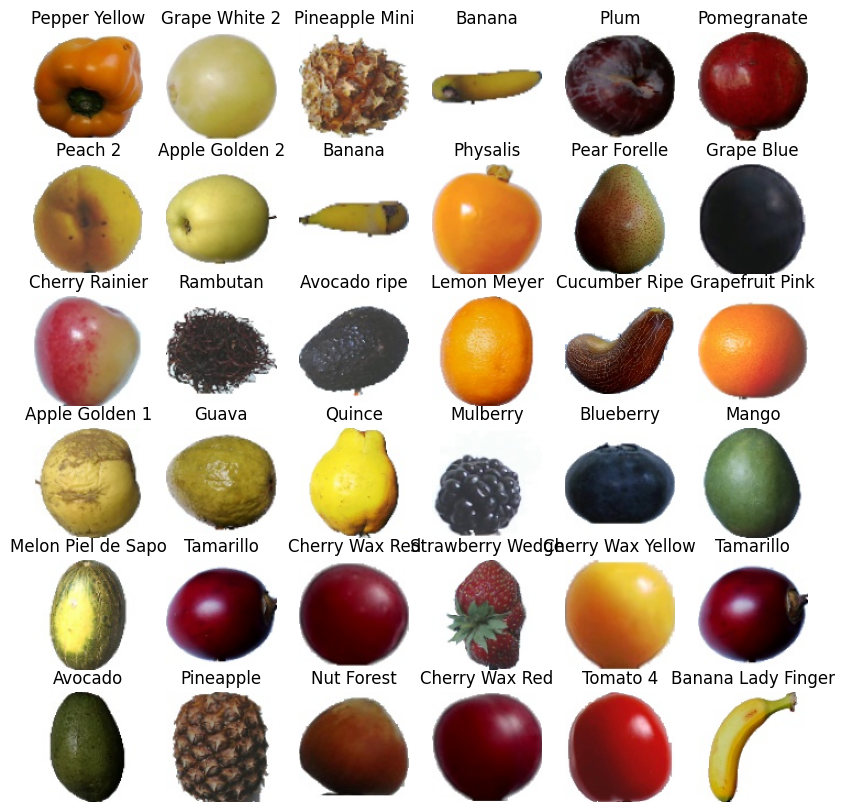

In [5]:
# ------------------------------------------------------------
# 5. Visualizar algunas imágenes (30x30 muestras)
# ------------------------------------------------------------
def show_batch(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(6, 6, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img = images[i] / 2 + 0.5  # desnormalizar
        npimg = img.numpy().transpose((1, 2, 0))
        ax.imshow(npimg)
        ax.axis('off')
        ax.set_title(train_dataset.dataset.classes[labels[i]])
    plt.show()

show_batch(train_loader)

## Definir modelo CNN

In [6]:
# ------------------------------------------------------------
# 6. Definir una CNN sencilla
# ------------------------------------------------------------
class FruitCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 25 * 25, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 25 * 25)
        x = self.drop(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

num_classes = len(train_dataset.dataset.classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FruitCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Entrenamiento

Época [1/10]  Train Loss: 0.4886  Val Loss: 0.0123  Val Acc: 99.65%
Época [2/10]  Train Loss: 0.0462  Val Loss: 0.0102  Val Acc: 99.65%
Época [3/10]  Train Loss: 0.0360  Val Loss: 0.0048  Val Acc: 99.87%
Época [4/10]  Train Loss: 0.0307  Val Loss: 0.0044  Val Acc: 99.91%
Época [5/10]  Train Loss: 0.0221  Val Loss: 0.0102  Val Acc: 99.69%
Época [6/10]  Train Loss: 0.0181  Val Loss: 0.0048  Val Acc: 99.90%
Época [7/10]  Train Loss: 0.0188  Val Loss: 0.0010  Val Acc: 99.99%
Época [8/10]  Train Loss: 0.0190  Val Loss: 0.0013  Val Acc: 99.99%
Época [9/10]  Train Loss: 0.0131  Val Loss: 0.0003  Val Acc: 99.99%
Época [10/10]  Train Loss: 0.0134  Val Loss: 0.0006  Val Acc: 99.99%


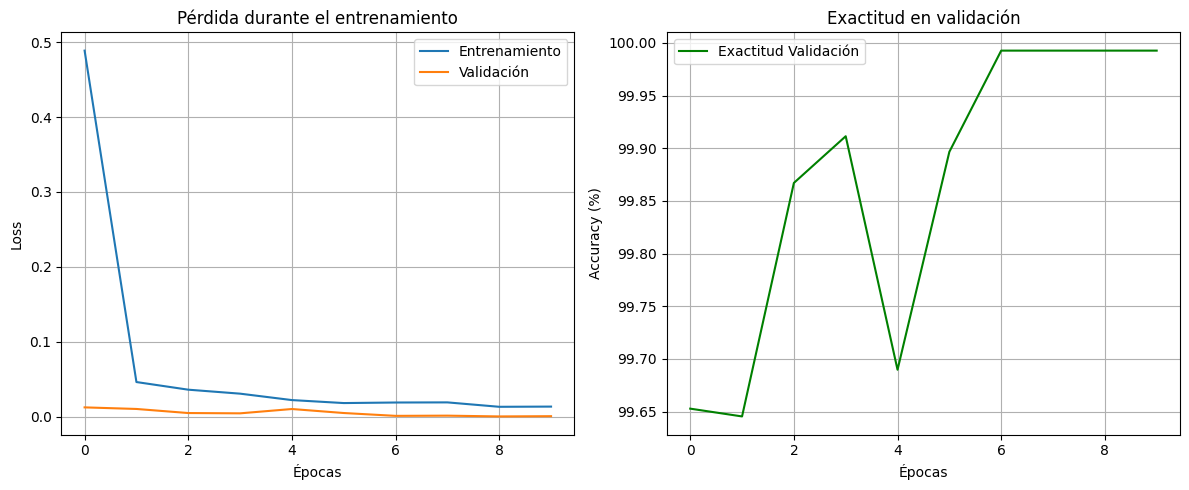

In [8]:
# ------------------------------------------------------------
# 7. Entrenamiento con validación
# ------------------------------------------------------------
num_epochs = 10

train_losses, val_losses = [], []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validación ----
    model.eval()
    correct, total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Época [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss/len(val_loader):.4f}  "
          f"Val Acc: {val_acc:.2f}%")

# ------------------------------------------------------------
# 8. Graficar métricas de entrenamiento
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# --- Pérdida ---
plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Exactitud ---
plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Exactitud Validación', color='green')
plt.title('Exactitud en validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()